In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

In [2]:
url = 'https://gist.githubusercontent.com/alansastre/09c001813f9226a6061163d150db5d5d/raw/7f8977efe2dce75b20b164062925fab6f71b8ca5/weather.csv'
df = pd.read_csv(url)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
# normalizo nombres de columnas
def normalizar_columnas(df):
      df = df.copy()
      df.columns = (
          df.columns
          .str.strip()
          .str.lower()
          .str.replace(" ", "_")
          .str.replace("(", "", regex=False)
          .str.replace(")", "", regex=False)
          .str.replace("%", "pct", regex=False)
      )
      return df
df = normalizar_columnas(df)
df.columns

Index(['temperature', 'humidity', 'wind_speed', 'precipitation_pct',
       'cloud_cover', 'atmospheric_pressure', 'uv_index', 'season',
       'visibility_km', 'location', 'weather_type'],
      dtype='str')

In [4]:
df.shape

(13200, 11)

In [5]:
df.info() # bonus: me dice los tipos de datos

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature           13200 non-null  float64
 1   humidity              13200 non-null  int64  
 2   wind_speed            13200 non-null  float64
 3   precipitation_pct     13200 non-null  float64
 4   cloud_cover           13200 non-null  str    
 5   atmospheric_pressure  13200 non-null  float64
 6   uv_index              13200 non-null  int64  
 7   season                13200 non-null  str    
 8   visibility_km         13200 non-null  float64
 9   location              13200 non-null  str    
 10  weather_type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.5 MB


Vemos que 'Weather Type' es type: string; almacena texto, y su contenido representa categorías fijas y finitas:
- rainy
- cloudy
- sunny
- snowy

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temperature,13200.0,NaN,NaN,NaN,19.127576,17.386327,-25.0,4.0,21.0,31.0,109.0
humidity,13200.0,NaN,NaN,NaN,68.710833,20.194248,20.0,57.0,70.0,84.0,109.0
wind_speed,13200.0,NaN,NaN,NaN,9.832197,6.908704,0.0,5.0,9.0,13.5,48.5
precipitation_pct,13200.0,NaN,NaN,NaN,53.644394,31.946541,0.0,19.0,58.0,82.0,109.0
cloud_cover,13200,4,overcast,6090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atmospheric_pressure,13200.0,NaN,NaN,NaN,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21
uv_index,13200.0,NaN,NaN,NaN,4.005758,3.8566,0.0,1.0,3.0,7.0,14.0
season,13200,4,Winter,5610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visibility_km,13200.0,NaN,NaN,NaN,5.462917,3.371499,0.0,3.0,5.0,7.5,20.0
location,13200,3,inland,4816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# los gráficos muestran valores extremos que pueden presentar errores, como 109 en humedad, que es imposible, al medirse en %.
# busco esos valor en el dataframe y muestro las filas que lo contienen, 
# y los tendremos en cuenta para limpiar los datos y evitar erroes.

valor_buscado = 109 

resultado = df[df.eq(valor_buscado).any(axis=1)]
print(resultado)

       temperature  humidity  wind_speed  precipitation_pct    cloud_cover  \
37             2.0       105        19.0              109.0       overcast   
262           44.0        94         9.0              109.0          clear   
292            2.0       105        10.5              109.0       overcast   
379           37.0       109        22.0               94.0       overcast   
390           18.0        94         2.5              109.0  partly cloudy   
...            ...       ...         ...                ...            ...   
12364         44.0       109        23.0               83.0       overcast   
12566          4.0       109        16.0               93.0       overcast   
12667         30.0        74         6.5              109.0          clear   
12672         61.0       109        32.0               93.0  partly cloudy   
13025         66.0       100         7.0              109.0          clear   

       atmospheric_pressure  uv_index  season  visibility_km  l

In [8]:
print("conteo de valores únicos")
df["weather_type"].value_counts()

conteo de valores únicos


weather_type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

Usando value_counts concluimos que la variable weather_type está totalmente balanceada con 3300 registros de cada tipo de clima.

In [9]:
# defnimimos las variables numéricas que vamos a usar para el análisis
numeric_cols = [
    "temperature",
    "humidity",
    "wind_speed",
    "precipitation_pct",
    "atmospheric_pressure",
    "uv_index",
    "visibility_km"
]

In [10]:
# defnimimos las variables categóricas que vamos a usar para el análisis
categorical_cols = [
    "cloud_cover",
    "season",
    "location"]

# Análisis exploratorio de datos (EDA)

Para identificar posibles correlaciones y distribuciones entre los datos del conjunto, dibujamos los gráficos necesarios usando varias librerías para visualización de datos.

Visualizamos la distribución de registros de temperatura y demás variables numéricas con un histograma usando plotly express.

In [11]:
fig = px.histogram(
    df,
    x="temperature",
    nbins=30,
    marginal="box",
    title="distribución de temperatura",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Temperatura (°C)",
    yaxis_title="Frecuencia",
)

fig.show()

Gracias a este gráfico podemos ver registros de temperatura con un rango desde -21 ºC hasta los 109 ºC, incluyendo también la frecuencia con la que se registra cada valor. No eliminamos los valores extremos para descartar primero si representan errores o situaciones meteorológicas válidas.

El rango más registrado de temperatura es entre 30 y 34 grados Celsius, con un conteo de 1784 registros, y la distribución no es necesariamente simétrica, aunque se concentra entre -10º y 44º.

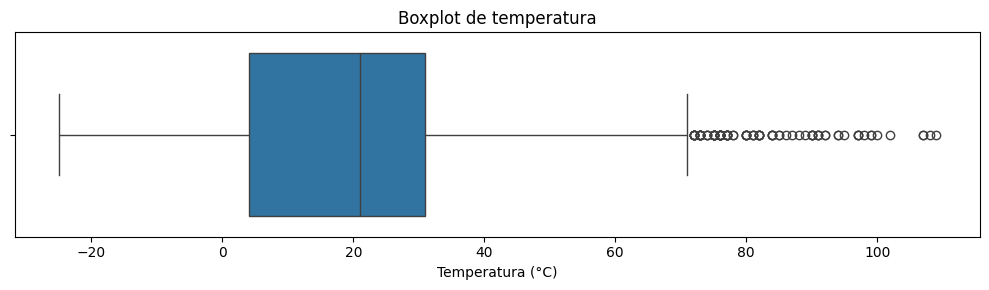

In [12]:
plt.figure(figsize=(10, 3))

sns.boxplot(data=df, x="temperature")

plt.title("Boxplot de temperatura")
plt.xlabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

El boxplot muestra la mediana, la dispersión central y los valores extremos de la temperatura. Se observan varios registros alejados del rango principal, por lo que será necesario revisar si corresponden a valores válidos o a posibles errores antes del modelado.

In [13]:
fig = px.histogram(df, x="humidity", nbins=40, marginal="box")
fig.show()

Este histograma nos muestra un patrón de registros de humedad acumulativo hacia el centro del rango, 
teniendo la mayor cantidad de registros entre 55% y 94%. El gráfico revela registros mayores a 100%, lo que puede indicar una contaminación o errores en la data.

In [14]:
fig = px.histogram(df, x="wind_speed", nbins=40, marginal="box")
fig.show()

La velocidad del viento se concentra principalmente en valores bajos, aunque también aparecen registros más elevados. La distribución presenta cierta dispersión y algunos valores extremos que conviene revisar antes de entrenar los modelos.

In [15]:
fig = px.histogram(df, x="precipitation_pct", nbins=40, marginal="box")
fig.show()

La precipitación se concentra principalmente entre valores bajos y medios, aunque aparecen registros superiores al 100%. Estos valores pueden indicar errores o contaminación en los datos y deberán revisarse durante la limpieza.

In [16]:
fig = px.histogram(
    df,
    x="atmospheric_pressure",
    nbins=40,
    marginal="box",
    title="distribución de presión atmosférica",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Presión atmosférica",
    yaxis_title="Frecuencia",
)

fig.show()

La presión atmosférica se concentra aproximadamente alrededor de 1000 y 1017, pero también presenta valores extremos cercanos a 800 y 1200. Estos valores pueden ser outliers o errores de medición, por lo que conviene conservarlos provisionalmente y revisarlos durante la limpieza.

In [17]:
fig = px.histogram(
    df,
    x="uv_index",
    nbins=40,
    marginal="box",
    title="distribución del índice UV",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Índice UV",
    yaxis_title="Frecuencia",
)

fig.show()

El índice UV se concentra principalmente en valores bajos e intermedios, aunque también aparecen registros cercanos a 14. La variable presenta variabilidad suficiente para poder aportar información al clasificar los distintos tipos de clima.

In [18]:
fig = px.histogram(
    df,
    x="visibility_km",
    nbins=40,
    marginal="box",
    title="distribución de visibilidad",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Visibilidad (km)",
    yaxis_title="Frecuencia",
)

fig.show()

La visibilidad se concentra principalmente en valores bajos e intermedios, aunque el rango llega hasta 20 km. También se observan registros cercanos a cero, que pueden representar condiciones meteorológicas de baja visibilidad o valores que será necesario revisar.

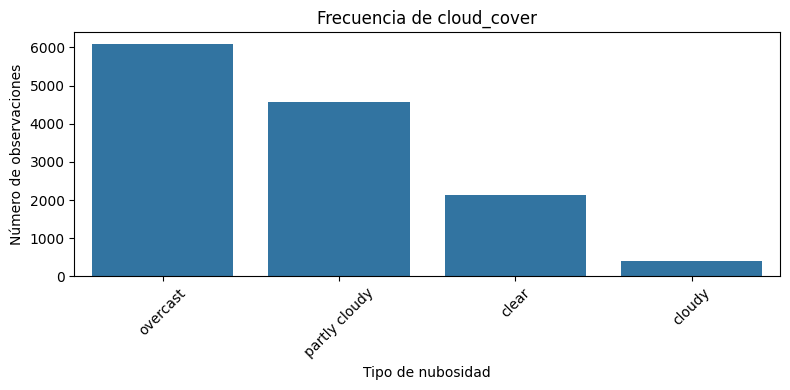

In [19]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="cloud_cover",
    order=df["cloud_cover"].value_counts().index
)

plt.title("Frecuencia de cloud_cover")
plt.xlabel("Tipo de nubosidad")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La categoría más frecuente de nubosidad (cloud_cover) es overcast, seguida de partly cloudy. La categoría cloudy presenta una frecuencia mucho menor, por lo que la distribución de esta variable categórica no es equilibrada.

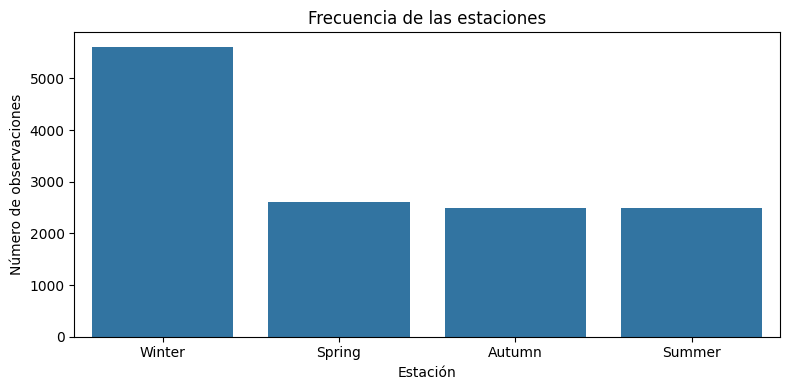

In [20]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="season",
    order=df["season"].value_counts().index
)

plt.title("Frecuencia de las estaciones")
plt.xlabel("Estación")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

La estación con mayor número de registros es Winter, mientras que Spring, Autumn y Summer presentan frecuencias bastante similares entre sí. Por tanto, la distribución de season está condicionada principalmente por la mayor presencia de invierno.

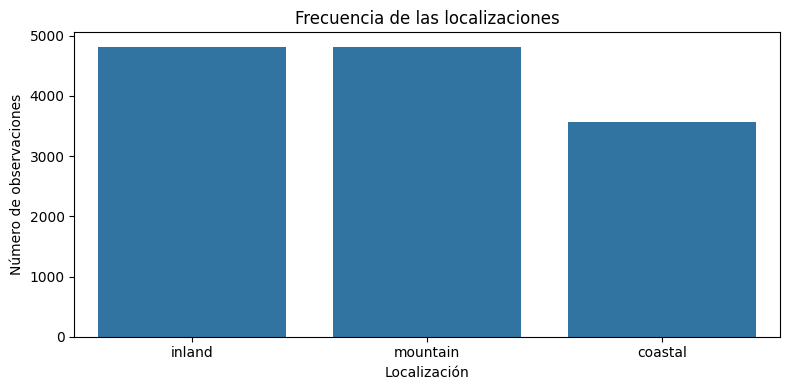

In [21]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="location",
    order=df["location"].value_counts().index
)

plt.title("Frecuencia de las localizaciones")
plt.xlabel("Localización")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

Las localizaciones inland y mountain presentan una frecuencia muy parecida y son las más representadas. La localización coastal tiene menos observaciones, aunque sigue teniendo un número suficiente de registros para utilizarla como variable categórica.

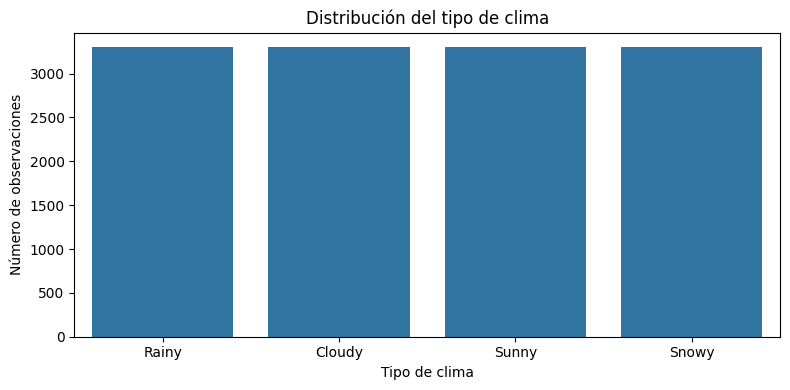

In [22]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="weather_type",
    order=df["weather_type"].value_counts().index
)

plt.title("Distribución del tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

Las cuatro categorías de weather_type tienen exactamente 3300 registros cada una. Por tanto, la variable objetivo está totalmente balanceada y no parece necesario aplicar técnicas de sobremuestreo o submuestreo por este motivo.

En esta sección analizamos cómo se relacionan las variables predictoras con el tipo de clima. Primero estudiamos las variables numéricas y después las variables categóricas.

Utilizamos boxplots para comparar la distribución de cada variable numérica entre las diferentes categorías de weather_type.

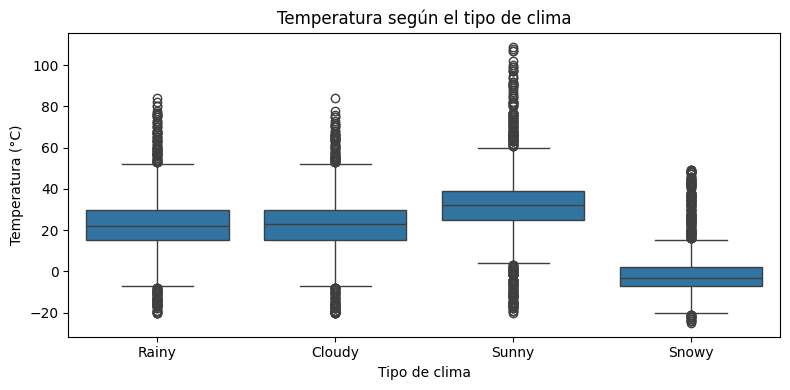

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="temperature")
plt.title("Temperatura según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

El boxplot muestra diferencias en la distribución de la temperatura según el tipo de clima. La separación entre algunas medianas sugiere que esta variable podría ayudar a distinguir las clases, aunque también existe cierto solapamiento.

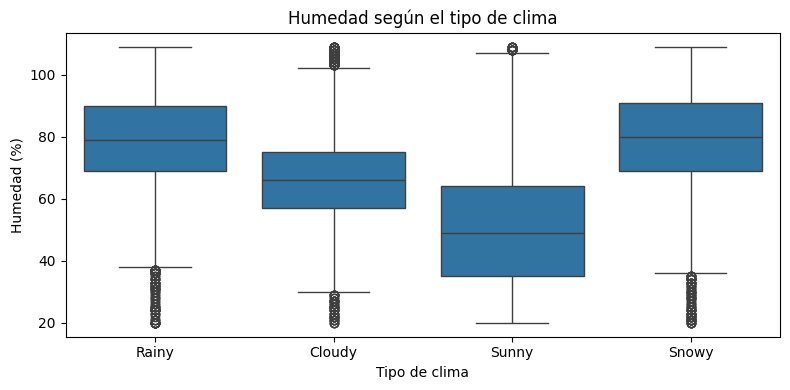

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="humidity")
plt.title("Humedad según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Humedad (%)")
plt.tight_layout()
plt.show()

La humedad presenta distribuciones diferentes entre los tipos de clima. Las diferencias entre medianas y rangos pueden aportar información para la clasificación, aunque los valores extremos deben interpretarse con precaución.

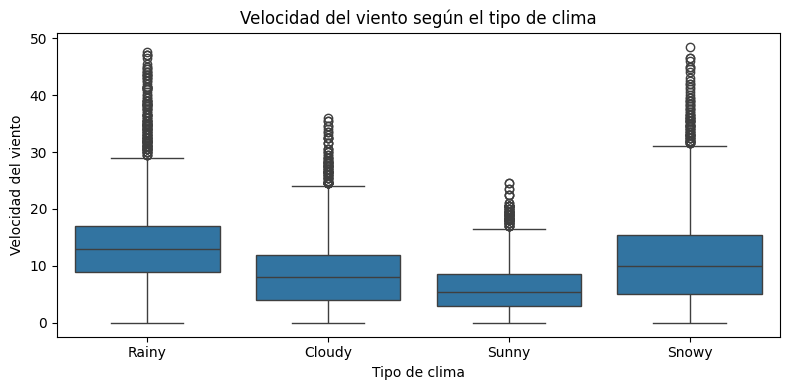

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="wind_speed")
plt.title("Velocidad del viento según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Velocidad del viento")
plt.tight_layout()
plt.show()

La velocidad del viento muestra cierto solapamiento entre las clases, aunque algunos tipos de clima presentan una mayor dispersión. Por sí sola podría no separar completamente las categorías, pero puede aportar información junto con el resto de variables.

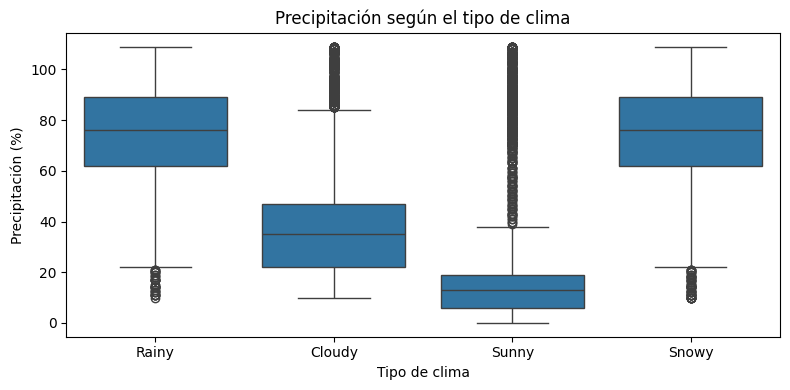

In [26]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="precipitation_pct")
plt.title("Precipitación según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Precipitación (%)")
plt.tight_layout()
plt.show()

La precipitación presenta diferencias visibles entre las categorías de weather_type. Esta variable podría ser útil para distinguir especialmente los tipos de clima más húmedos, aunque los valores superiores al 100% deben revisarse.

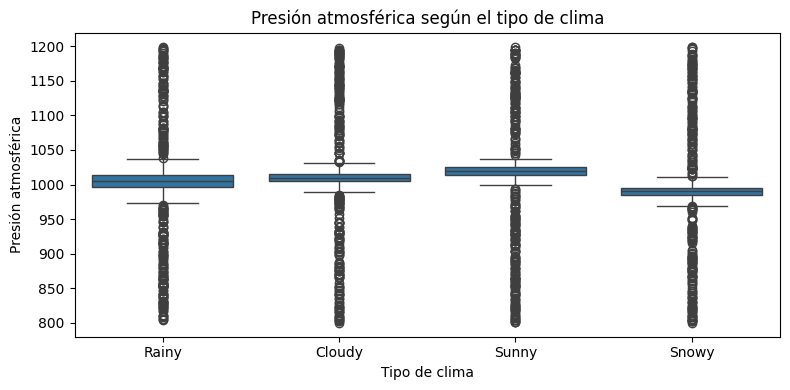

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="atmospheric_pressure")
plt.title("Presión atmosférica según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Presión atmosférica")
plt.tight_layout()
plt.show()

Las distribuciones de presión atmosférica presentan diferencias entre algunas categorías, aunque también existe solapamiento. Los valores extremos observados en el análisis univariante pueden influir en esta comparación y deberán revisarse.

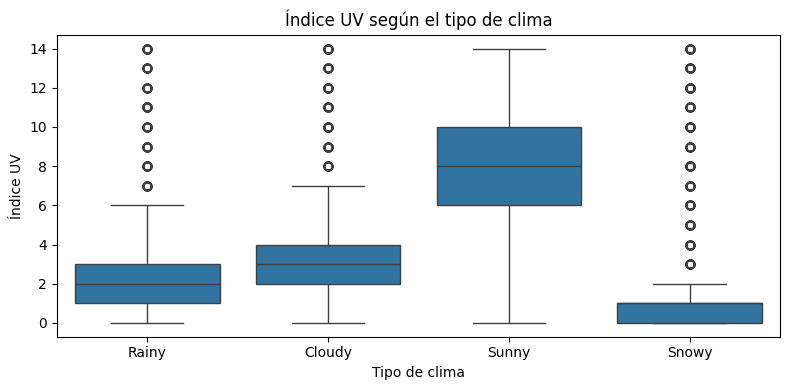

In [28]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="uv_index")
plt.title("Índice UV según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Índice UV")
plt.tight_layout()
plt.show()

El índice UV presenta diferencias entre las categorías de weather_type. Los valores más altos pueden estar asociados a determinados tipos de clima, por lo que esta variable podría contribuir a separar las clases.

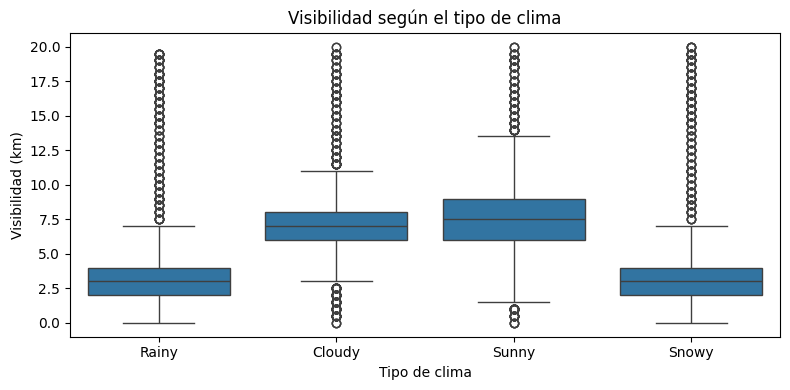

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="weather_type", y="visibility_km")
plt.title("Visibilidad según el tipo de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Visibilidad (km)")
plt.tight_layout()
plt.show()

La visibilidad muestra diferencias entre algunos tipos de clima, aunque las cajas también presentan solapamiento. Las observaciones cercanas a cero deben revisarse porque pueden representar condiciones de baja visibilidad o valores anómalos.

### Variables categóricas frente a weather_type

Utilizamos countplots agrupados para observar cómo se distribuyen las categorías de weather_type dentro de cada variable categórica predictora.

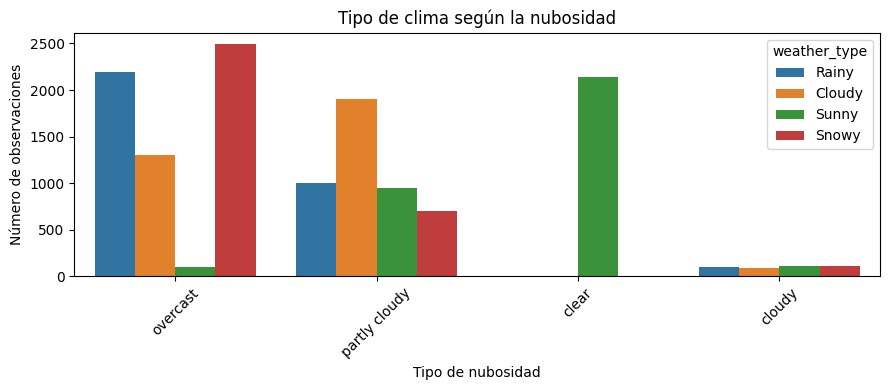

In [30]:
plt.figure(figsize=(9, 4))
sns.countplot(
    data=df,
    x="cloud_cover",
    hue="weather_type",
    order=df["cloud_cover"].value_counts().index
)
plt.title("Tipo de clima según la nubosidad")
plt.xlabel("Tipo de nubosidad")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La distribución de weather_type cambia según la categoría de nubosidad. Algunas categorías concentran determinados tipos de clima, aunque las frecuencias absolutas también están condicionadas por el desequilibrio observado en cloud_cover.

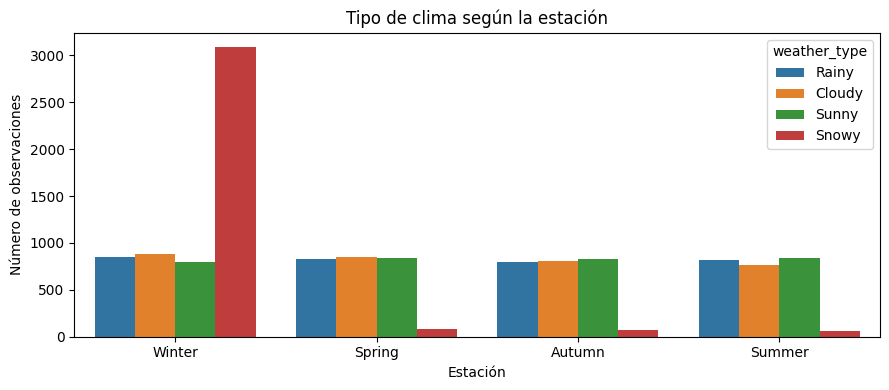

In [31]:
plt.figure(figsize=(9, 4))
sns.countplot(
    data=df,
    x="season",
    hue="weather_type",
    order=df["season"].value_counts().index
)
plt.title("Tipo de clima según la estación")
plt.xlabel("Estación")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

Las frecuencias de weather_type no parecen distribuirse de la misma forma en todas las estaciones. Winter tiene más observaciones totales, por lo que para comparar proporciones entre estaciones será conveniente considerar también frecuencias relativas.

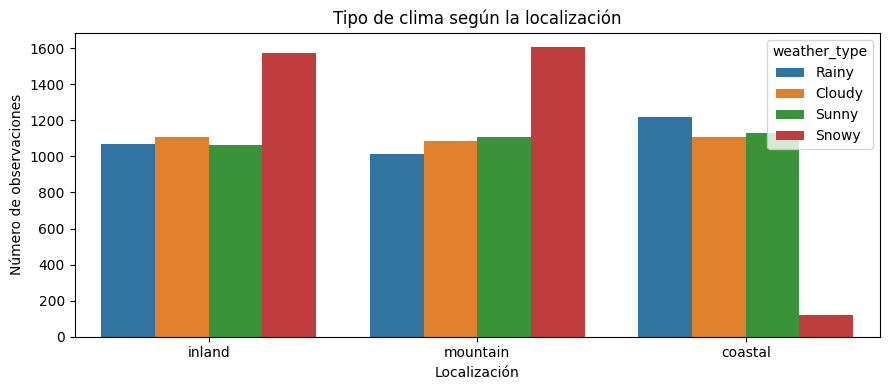

In [32]:
plt.figure(figsize=(9, 4))
sns.countplot(
    data=df,
    x="location",
    hue="weather_type",
    order=df["location"].value_counts().index
)
plt.title("Tipo de clima según la localización")
plt.xlabel("Localización")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

La distribución de los tipos de clima presenta diferencias entre las localizaciones. Inland y mountain tienen más observaciones que coastal, por lo que conviene interpretar las frecuencias absolutas junto con el tamaño de cada grupo.

Usando un heatmap podemos ver una matriz de correlación entre las múltiples variables de nuestro dataset.

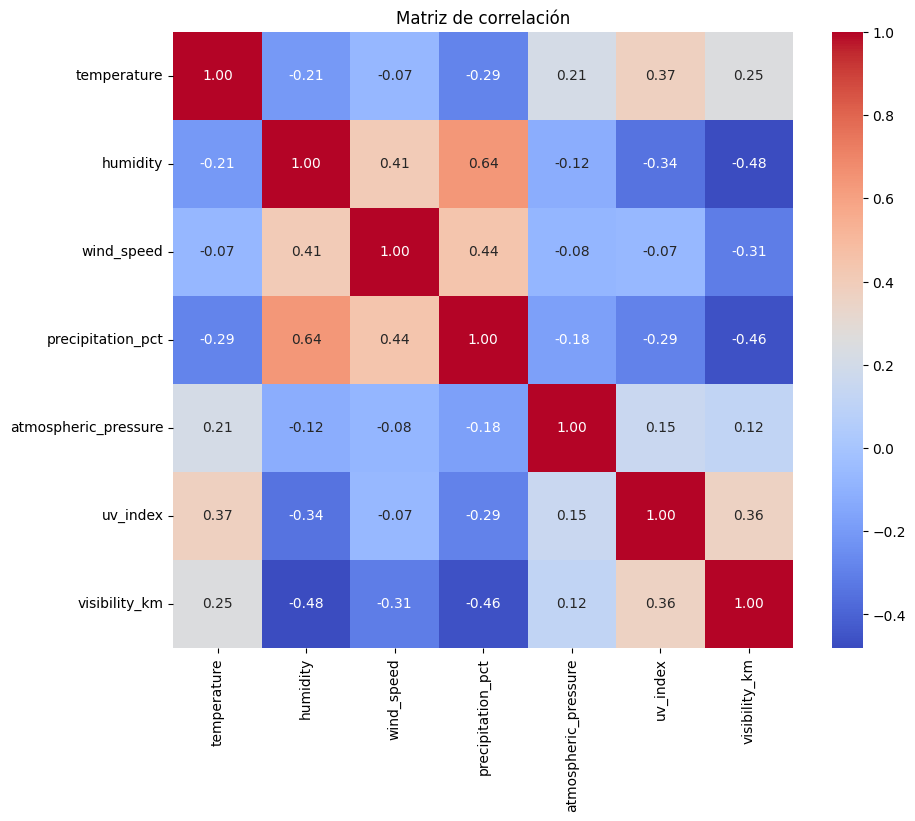

In [33]:
def correlation_matrix(df, numeric_cols):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matriz de correlación")
    plt.show()
correlation_matrix(df, numeric_cols)

Agrupamos variables numéricas según la similitud de sus correlaciones, usando un clustermap de seaborn. 
Esto nos permite visualizar las variables que puedan estar correlacionadas con patrones similares, e identificar posibles redundancias entre variables.

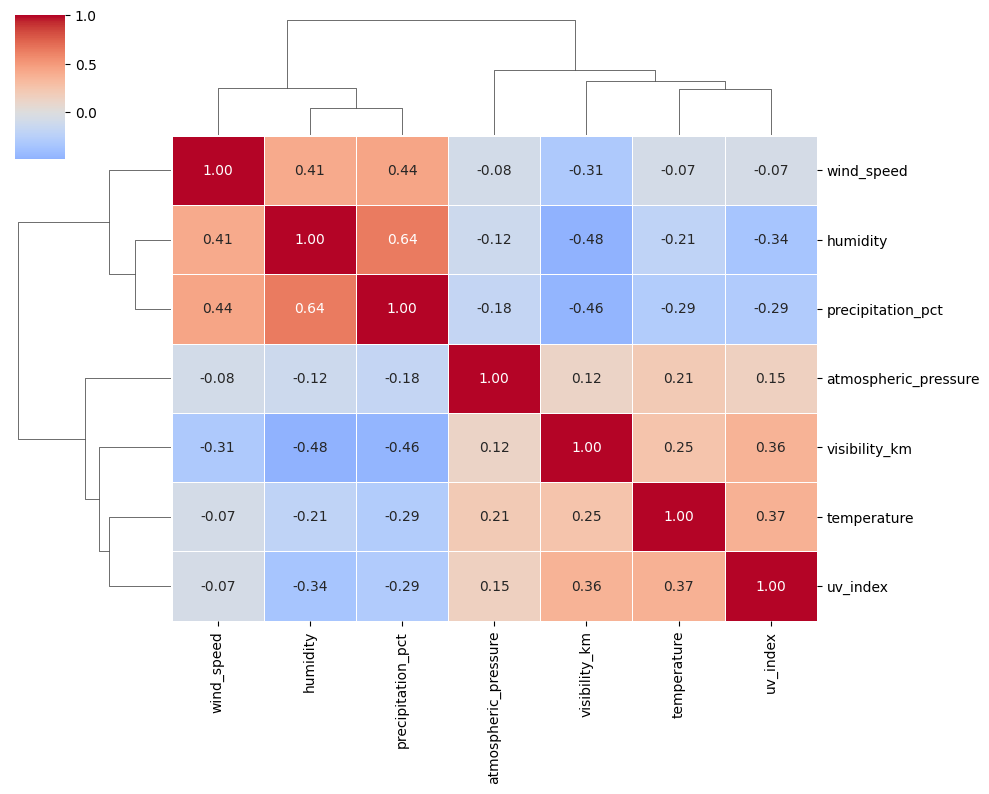

In [34]:
corr = df.select_dtypes(include="number").corr()

sns.clustermap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    figsize=(10, 8)
)

Según los heatmaps, podemos observar una correlación notable entre las variables de humedad y precipitación. Me pregunto, ¿cómo se relacionarán con el tipo de clima?

In [35]:
fig = px.scatter(
    df,
    x="humidity",
    y="precipitation_pct",
    color="weather_type",
    opacity=0.35,
    marginal_x="box",
    marginal_y="box",
    title="Relación entre humedad, precipitación y tipo de clima",
    template="plotly_white"
)

fig.show()

En este scatter plot vemos una distinción con forma de bloques que nos puede ayudar a distinguir el tipo de clima. 

Según el gráfico, vemos que la humedad y precipitación se relacionan entre sí: a mayor humedad, suele subir también la variable de precipitación. A pesar del ruido de fondo, vemos que hay un ligero solapamiento entre los rangos, pero se observa claramente una distinción entre cada tipo de clima y los valores registrados de humedad y precipitación.

Esta relación no es concluyente para predecir el tipo de clima.

In [36]:
fig = px.scatter(
    df,
    x="temperature",
    y="humidity",
    color="weather_type",
    opacity=0.35,
    title="Relación entre temperatura, humedad y tipo de clima",
    template="plotly_white"
)

fig.show()

Nuevamente observamos cuatro bloques densos en los que se define el núcleo de cada tipo de clima de manera lógica:
- snowy: alta concentración en bajas temperaturas y alta humedad para que pueda nevar.
- rainy: temperaturas templadas o cálidas y alta humedad.
- cloudy: temperaturas similares al clima lluvioso, pero con valores de humedad ligeramente menores, con solapamiento.
- sunny: altas temperaturas y baja humedad.

In [37]:
fig = px.scatter_matrix(
    df,
    dimensions=['temperature', 'humidity', 'wind_speed', 'precipitation_pct', 'atmospheric_pressure', 'uv_index', 'visibility_km'],
    color='weather_type',
    title="Matriz de Dispersión de Clima",
    opacity=0.3,          # Clave para ver los colores que quedan debajo
    labels={col: col.replace('_', ' ') for col in df.columns}
)

# Hacer los puntos más pequeños para evitar el colapso visual
fig.update_traces(marker=dict(size=3))
fig.update_layout(width=1000, height=900)
fig.show()

Al dibujar esta matriz de dispersión, vemos muchos patrones 'perfectos' en diferentes variables:
- rectángulos
- líneas con ángulos rectos
- concentración simétrica en puntos específicos

El reto que tendremos será el ruido de fondo al momento de hacer las predicciones.

## Limpieza y preparación de los datos

Comprobamos la calidad del conjunto, separamos predictores y objetivo, codificamos `y` con `LabelEncoder` y dejamos el preprocesamiento de `X` dentro de un `ColumnTransformer`. La partición se realiza antes de ajustar imputadores, encoder y scaler para evitar fuga de información.

Aunque no haya valores nulos inicialmente, convertiremos algunos valores físicamente inválidos en `NaN`. La imputación se realizará después del `train_test_split`, dentro del pipeline, para evitar fuga de información.

Los criterios se basan en límites físicos y en el contexto de este conjunto: humedad y precipitación son porcentajes, por lo que no pueden superar el 100 %, y una temperatura ambiental superior a 60 °C se trata como no plausible. No eliminamos filas para no alterar la distribución de `weather_type`: marcamos esos valores como `NaN` y el imputador los estima usando solo los datos de entrenamiento. Conservamos una visibilidad de 0 km, que puede representar niebla densa, y la presión extrema como observación sospechosa porque no contamos con una regla de dominio suficiente para corregirla.

In [38]:
# conservamos df intacto para el EDA y creamos una copia para el modelado.
df_model = df.copy()

# convertimos en NaN los valores físicamente inválidos para sus unidades.
invalid_masks = {
    "temperature": df_model["temperature"] > 60,
    "humidity": df_model["humidity"] > 100,
    "precipitation_pct": df_model["precipitation_pct"] > 100,
}

invalid_counts = {column: int(mask.sum()) for column, mask in invalid_masks.items()}
for column, mask in invalid_masks.items():
    df_model.loc[mask, column] = np.nan

print("valores convertidos a NaN:", invalid_counts)
print("nulos después de la limpieza:")
print(df_model[list(invalid_masks)].isna().sum())

# la visibilidad igual a 0 puede representar visibilidad nula y se conserva.
# la presión extrema se conserva como observación sospechosa.

valores convertidos a NaN: {'temperature': 207, 'humidity': 416, 'precipitation_pct': 392}
nulos después de la limpieza:
temperature          207
humidity             416
precipitation_pct    392
dtype: int64


Definimos `X` e `y`, conservando las categorías de `X` en su formato original.
El encoding se aplicará más adelante dentro del `ColumnTransformer`, tras la partición,
para evitar fuga de información.

Defino los selectores de columnas para separar las variables numéricas y categóricas.

In [39]:
# separamos predictores y objetivo sin codificar todavía las categorías de X.
X = df_model.drop(columns='weather_type').copy()
y = df_model['weather_type'].copy()

# Los selectores identifican las columnas que recibirá cada pipeline.
selector_numerical = make_column_selector(dtype_include='number')
selector_categorical = make_column_selector(dtype_exclude='number')

print('numerical_cols: ', selector_numerical(X))
print('categorical_cols: ', selector_categorical(X))

numerical_cols:  ['temperature', 'humidity', 'wind_speed', 'precipitation_pct', 'atmospheric_pressure', 'uv_index', 'visibility_km']
categorical_cols:  ['cloud_cover', 'season', 'location']


Aquí pasamos a implementar pipelines de transformación y ajustamos los números
para que tengan una escala similar. Esto es útil para comparar diferentes variables con magnitudes coherentes. 
(ej: contexto == persona --> peso en kg, temperatura en ºC, edad en años)

- columnas numéricas: rellenamos con la mediana los valores numéricos faltantes.
- columnas categóricas: rellenamos con el valor más frecuente los valores categóricos faltantes.

Aplicamos encoding a las variabes categóricas para volverlas numéricas.

In [40]:
# pipelines
pipeline_numerical = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorical = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# unificamos ambos pipelines
preprocessed = ColumnTransformer([
    ('numerical', pipeline_numerical, selector_numerical),
    ('categorical', pipeline_categorical, selector_categorical)
])

In [41]:
# codificamos la variable objetivo categórica.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# partición estratificada 80/20 con semilla reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print('clases originales:', label_encoder.classes_)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

clases originales: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']
X_train: (10560, 10) | X_test: (2640, 10)
y_train: (10560,) | y_test: (2640,)


In [42]:
# ajustamos el preprocesamiento solo con train y lo aplicamos a train y test.
X_train_prepared = preprocessed.fit_transform(X_train)
X_test_prepared = preprocessed.transform(X_test)

feature_names = preprocessed.get_feature_names_out()

print('Variables resultantes:', len(feature_names))
print('X_train_prepared:', X_train_prepared.shape)
print('X_test_prepared:', X_test_prepared.shape)
print('Nulos en X_train_prepared:', int(pd.isna(X_train_prepared).sum()))
print('Nulos en X_test_prepared:', int(pd.isna(X_test_prepared).sum()))

assert X_train.shape[0] == 10560
assert X_test.shape[0] == 2640
assert X_train_prepared.shape[1] == X_test_prepared.shape[1]
assert pd.isna(X_train_prepared).sum() == 0
assert pd.isna(X_test_prepared).sum() == 0

Variables resultantes: 15
X_train_prepared: (10560, 15)
X_test_prepared: (2640, 15)
Nulos en X_train_prepared: 0
Nulos en X_test_prepared: 0


## Pipelines de clasificación

Usaremos dos modelos de predicción: un LogisticRegression y un RandomForest. Cada pipeline contiene su propia copia del preprocesador para que el ajuste de imputación, encoding y escalado sea independiente y reproducible.

Compararemos un modelo lineal frente a un random forest para tener dos enfoques diferentes, que nos permitirá descubrir si el problema se puede resolver con relaciones simples o necesita combinaciones más complejas.

Antes de evaluar una única partición de prueba, aplicaremos validación cruzada estratificada de 5 folds sobre `X_train`. Así comprobamos la estabilidad de cada pipeline sin tocar `X_test`, que queda reservado para la evaluación final.

## Métricas de evaluación

Para comparar los modelos de clasificación multiclase utilizaremos cuatro métricas. Cada una observa el rendimiento desde una perspectiva diferente:

| Métrica | Pregunta principal | Qué mide |
|:--|:--|:--|
| **Accuracy** | ¿Cuántas predicciones fueron correctas en total? | Proporción global de aciertos. |
| **Precision** | Cuando el modelo asigna una clase, ¿con qué frecuencia acierta? | Calidad de las predicciones de cada clase. |
| **Recall** | De los casos que realmente pertenecen a una clase, ¿cuántos detecta? | Capacidad para encontrar los casos de cada clase. |
| **F1-score** | ¿Existe un equilibrio entre precision y recall? | Media armónica entre ambas métricas. |

### Fórmulas conceptuales

- **Accuracy** = aciertos totales / número total de casos
- **Precision** = verdaderos positivos / (verdaderos positivos + falsos positivos)
- **Recall** = verdaderos positivos / (verdaderos positivos + falsos negativos)
- **F1-score** = 2 × (precision × recall) / (precision + recall)

> Como el problema tiene varias clases, `precision`, `recall` y `f1-score` se calculan con `average='macro'`: primero se calcula la métrica para cada clase y después se obtiene su promedio, dando el mismo peso a todas las clases.

In [43]:
model_pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessed", clone(preprocessed)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("preprocessed", clone(preprocessed)),
        ("model", RandomForestClassifier(random_state=42))
    ])
}

# Validamos cada pipeline únicamente con el conjunto de entrenamiento.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_rows = []
for name, model_pipeline in model_pipelines.items():
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_rows.append({
        'modelo': name,
        **{
            f'{metric}_media': scores[f'test_{metric}'].mean()
            for metric in scoring
        },
        **{
            f'{metric}_desv': scores[f'test_{metric}'].std()
            for metric in scoring
        }
    })

cv_results_df = pd.DataFrame(cv_rows).set_index('modelo')
display(cv_results_df.round(3))

# Ajustamos cada pipeline con todo X_train antes de la evaluación final.
for name, model_pipeline in model_pipelines.items():
    model_pipeline.fit(X_train, y_train)
    predictions = model_pipeline.predict(X_test)
    print(f'{name}: entrenamiento y predicción correctos | predicciones: {predictions.shape}')

,accuracy_media,precision_macro_media,recall_macro_media,f1_macro_media,accuracy_desv,precision_macro_desv,recall_macro_desv,f1_macro_desv
modelo,,,,,,,,
Logistic Regression,0.872,0.873,0.872,0.872,0.003,0.003,0.003,0.003
Random Forest,0.916,0.917,0.916,0.916,0.004,0.004,0.004,0.004


Logistic Regression: entrenamiento y predicción correctos | predicciones: (2640,)
Random Forest: entrenamiento y predicción correctos | predicciones: (2640,)


In [44]:
# guardamos las predicciones una sola vez para reutilizarlas en la evaluación.
predictions_by_model = {
    name: model_pipeline.predict(X_test)
    for name, model_pipeline in model_pipelines.items()
}

print('Predicciones guardadas para:', list(predictions_by_model))

Predicciones guardadas para: ['Logistic Regression', 'Random Forest']


In [45]:
accuracy_results = {
    name: accuracy_score(y_test, predictions)
    for name, predictions in predictions_by_model.items()
}

accuracy_results

{'Logistic Regression': 0.8647727272727272,
 'Random Forest': 0.9113636363636364}

Al comprarar la exactitud 'accuracy' de ambos modelos, vemos que el RandomForest es superior por un 5%.

In [46]:
precision_results = {
    name: precision_score(
        y_test, predictions, average='macro', zero_division=0
    )
    for name, predictions in predictions_by_model.items()
}

precision_results

{'Logistic Regression': 0.8657584274403188,
 'Random Forest': 0.9129590934741377}

Los resultados que arroja la precisión, nos indican que el RandomForest ha vuelto a ganar por un 5% frente al modelo de LogisticRegression.

In [47]:
recall_results = {
    name: recall_score(
        y_test, predictions, average='macro', zero_division=0
    )
    for name, predictions in predictions_by_model.items()
}

recall_results

{'Logistic Regression': 0.8647727272727272,
 'Random Forest': 0.9113636363636364}

Al evaluar los resultados del recall, vemos que el RandomForest ha rendido un 5% por encima de su competidor, otra vez.

In [48]:
f1_results = {
    name: f1_score(
        y_test, predictions, average='macro', zero_division=0
    )
    for name, predictions in predictions_by_model.items()
}

f1_results

{'Logistic Regression': 0.8649115293411775,
 'Random Forest': 0.9117597812143758}

Y para más INRI, los resultados del f1-score también favorecen con un gap del 5% al RandomForest para este ejercicio y dataset.

Podemos ver que no se trata de un error en el que se repiten los valores calculados para cada métrica si echamos un ojo a los decimales de cada resultado.

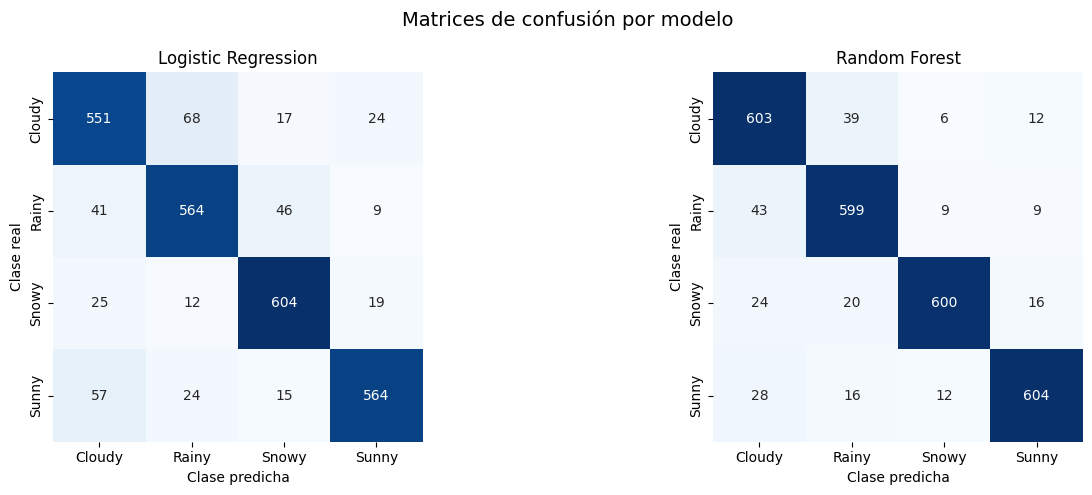

In [49]:
confusion_matrices = {
    name: confusion_matrix(y_test, predictions)
    for name, predictions in predictions_by_model.items()
}

class_names = label_encoder.classes_
fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(14, 5))

if len(confusion_matrices) == 1:
    axes = [axes]

for ax, (name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')

fig.suptitle('Matrices de confusión por modelo', fontsize=14)
plt.tight_layout()
plt.show()

Al tener lado a lado ambas matrices, es casi evidente notar que el modelo de LogisticRegression tiende más a equivocarse al predecir el tipo de clima que el RandomForest. Para hacer la interpretación:

- las filas representan la clase real.
- las columnas representan la clase predicha.
- la diagonal muestra los aciertos.
- los valores fuera de la diagonal son confusiones.

El único caso en el que LogisticRegression supera (muy ligeramente) al RandomForest es al predecir 'Snowy', sin indicar una mejora notable o significativa en la que valga la pena profundizar.

## Classification report

El `classification_report` resume el rendimiento de cada modelo para cada clase. Además de las métricas por clase, muestra los promedios macro y ponderado.

In [50]:
classification_reports = {}

for name, predictions in predictions_by_model.items():
    report = classification_report(
        y_test,
        predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T.round(3)
    classification_reports[name] = report_df

    print(f'{name}')
    display(report_df)


Logistic Regression


,precision,recall,f1-score,support
Cloudy,0.818,0.835,0.826,660.000
Rainy,0.844,0.855,0.849,660.000
Snowy,0.886,0.915,0.900,660.000
Sunny,0.916,0.855,0.884,660.000
accuracy,0.865,0.865,0.865,0.865
macro avg,0.866,0.865,0.865,2640.000
weighted avg,0.866,0.865,0.865,2640.000


Random Forest


,precision,recall,f1-score,support
Cloudy,0.864,0.914,0.888,660.000
Rainy,0.889,0.908,0.898,660.000
Snowy,0.957,0.909,0.932,660.000
Sunny,0.942,0.915,0.929,660.000
accuracy,0.911,0.911,0.911,0.911
macro avg,0.913,0.911,0.912,2640.000
weighted avg,0.913,0.911,0.912,2640.000


## Comparativa global de métricas

Reunimos las métricas calculadas en una tabla para compararlas de forma directa.

In [51]:
metrics_df = pd.DataFrame({
    'accuracy': accuracy_results,
    'precision': precision_results,
    'recall': recall_results,
    'f1_score': f1_results
})

metrics_df

,accuracy,precision,recall,f1_score
Logistic Regression,0.864773,0.865758,0.864773,0.864912
Random Forest,0.911364,0.912959,0.911364,0.911760


Esta tabla agrupa de forma sencilla y práctica los resultados de ambos modelos de predicción para su estudio y registro.

### Gráfico de barras

Comparamos los modelos en las cuatro métricas usando la misma escala de 0 a 1.

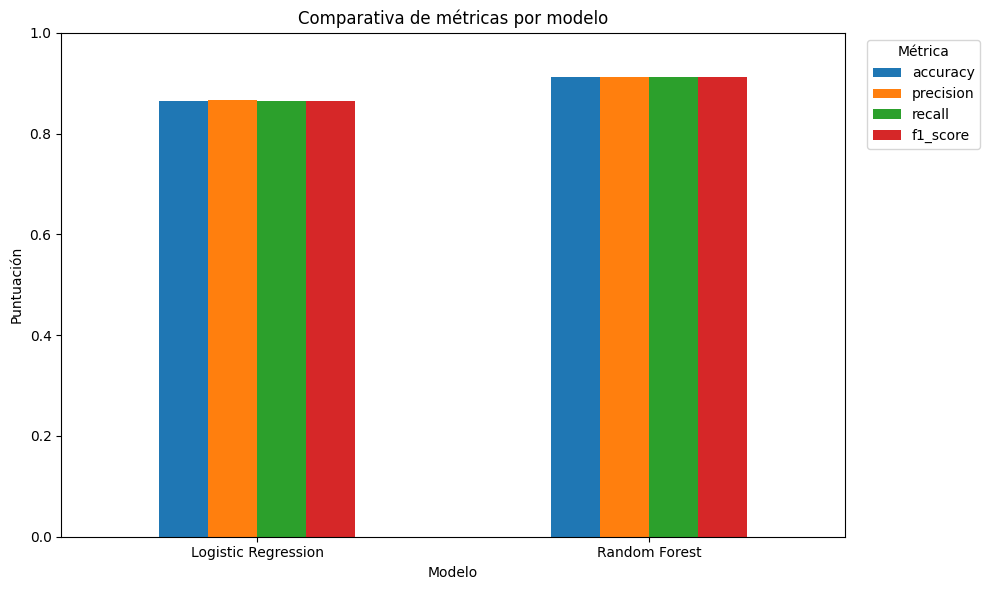

In [52]:
ax = metrics_df.plot(
    kind='bar',
    figsize=(10, 6),
    ylim=(0, 1),
    rot=0
)

ax.set_title('Comparativa de métricas por modelo')
ax.set_xlabel('Modelo')
ax.set_ylabel('Puntuación')
ax.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

En conclusión, el RandomForest es el mejor modelo porque muestra un comportamiento más consistente entre las clases predichas, reduce las confusiones fuera de la diagonal y tiene un mayor número de aciertos en total. El modelo ganador supera en un 4,66% a su alternativa.

El mayor reto sería distinguir entre Cloudy y Rainy, probablemente porque sus características meteorológicas se solapan y asemejan en gran medida, pues es común que cuando haya nubes, llueva, porque cuando el río suena...